# Ноутбук 4: Анализ товарных запасов и оборачиваемости

## 1. Что я делаю

В ноутбуке 02 я обнаружил, что хранение на складе FBO — крупнейшая статья логистических затрат (6.2 млн ₽, 55% всех логистических расходов). Это прямое следствие неоптимального управления запасами: товары лежат на складе месяцами и «съедают» маржу.

В этом ноутбуке я:
- Проведу **ABC-анализ** — выделю товары, приносящие 80% выручки.
- Проведу **XYZ-анализ** — оценю стабильность спроса на каждый товар.
- Построю **ABC-XYZ-матрицу** — дам стратегию управления запасами для каждой группы.
- Рассчитаю **оборачиваемость** — найду неликвиды и посчитаю замороженный капитал.
- Рассчитаю **оптимальный страховой запас** — сравню с текущими остатками.

Результат: конкретный план оптимизации закупок с оценкой финансового эффекта.

## 2. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

pd.set_option('display.float_format', '{:,.0f}'.format)

COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'warning': '#C73E1D',
    'success': '#3B1F2B',
    'profit': '#2E86AB',
    'loss': '#C73E1D',
}

In [3]:
DATA_PATH = "data/"

print("Загрузка данных...")

products = pd.read_csv(os.path.join(DATA_PATH, "products.csv"))
sales = pd.read_csv(os.path.join(DATA_PATH, "sales.csv"))
purchases = pd.read_csv(os.path.join(DATA_PATH, "purchases.csv"))

sales["order_date"] = pd.to_datetime(sales["order_date"])
sales["delivery_date"] = pd.to_datetime(sales["delivery_date"])
purchases["purchase_date"] = pd.to_datetime(purchases["purchase_date"])
purchases["delivery_date"] = pd.to_datetime(purchases["delivery_date"])

print(f"Загружено:")
print(f"  products: {len(products):,} товаров")
print(f"  sales: {len(sales):,} строк продаж")
print(f"  purchases: {len(purchases):,} закупок")

Загрузка данных...
Загружено:
  products: 3,000 товаров
  sales: 58,664 строк продаж
  purchases: 3,717 закупок


### 2.1. Агрегация данных по товарам

In [4]:
# Продажи по товарам
product_sales = sales.groupby("product_id").agg(
    total_sold=("product_id", "count"),
    total_revenue=("unit_price", "sum"),
    avg_price=("unit_price", "mean"),
).reset_index()

# Продажи по товарам помесячно (для XYZ)
sales["order_month"] = sales["order_date"].dt.to_period("M")
monthly_sales = sales.groupby(["product_id", "order_month"]).size().reset_index()
monthly_sales.columns = ["product_id", "order_month", "monthly_sold"]

# Закупки по товарам
product_purchases = purchases.groupby("product_id").agg(
    total_purchased=("quantity", "sum"),
    total_purchase_cost=("purchase_price", "sum"),
    avg_purchase_price=("purchase_price", "mean"),
    lead_time_days=("lead_time_days", "mean"),
).reset_index()

# Объединяю в единую витрину
inventory = products.merge(product_sales, on="product_id", how="left")
inventory = inventory.merge(product_purchases, on="product_id", how="left")

# Заполняю NaN (товары без продаж и закупок)
inventory["total_sold"].fillna(0, inplace=True)
inventory["total_revenue"].fillna(0, inplace=True)
inventory["total_purchased"].fillna(0, inplace=True)

# Средний остаток за период (упрощённо: закуплено − продано)
inventory["avg_stock"] = (inventory["total_purchased"] - inventory["total_sold"]).clip(lower=0)

print(f"\nТоваров с продажами: {(inventory['total_sold'] > 0).sum()}")
print(f"Товаров без продаж: {(inventory['total_sold'] == 0).sum()}")
print(f"Товаров с нулевыми закупками: {(inventory['total_purchased'] == 0).sum()}")
print(f"Средний остаток по всем товарам: {inventory['avg_stock'].mean():.0f} ед.")
print(f"Общая выручка: {inventory['total_revenue'].sum():,.0f} ₽")


Товаров с продажами: 2837
Товаров без продаж: 163
Товаров с нулевыми закупками: 0
Средний остаток по всем товарам: 18 ед.
Общая выручка: 14,537,459 ₽


## 3. ABC-анализ

ABC-анализ делит товары на три группы по их вкладу в выручку:

- **A** — 20% товаров, дающие 80% выручки. Ключевой ассортимент.
- **B** — 30% товаров, дающие 15% выручки. Средний слой.
- **C** — 50% товаров, дающие 5% выручки. Низкооборачиваемый ассортимент.

Это помогает понять, на каких товарах фокусировать усилия по управлению запасами.

### 3.1. ABC-анализ по выручке

abc_class  products  total_revenue  total_sold  product_share  revenue_share  sold_share
        A      1033     11,628,529      37,983             36             80          65
        B       858      2,180,954      14,433             30             15          25
        C       946        727,976       6,248             33              5          11


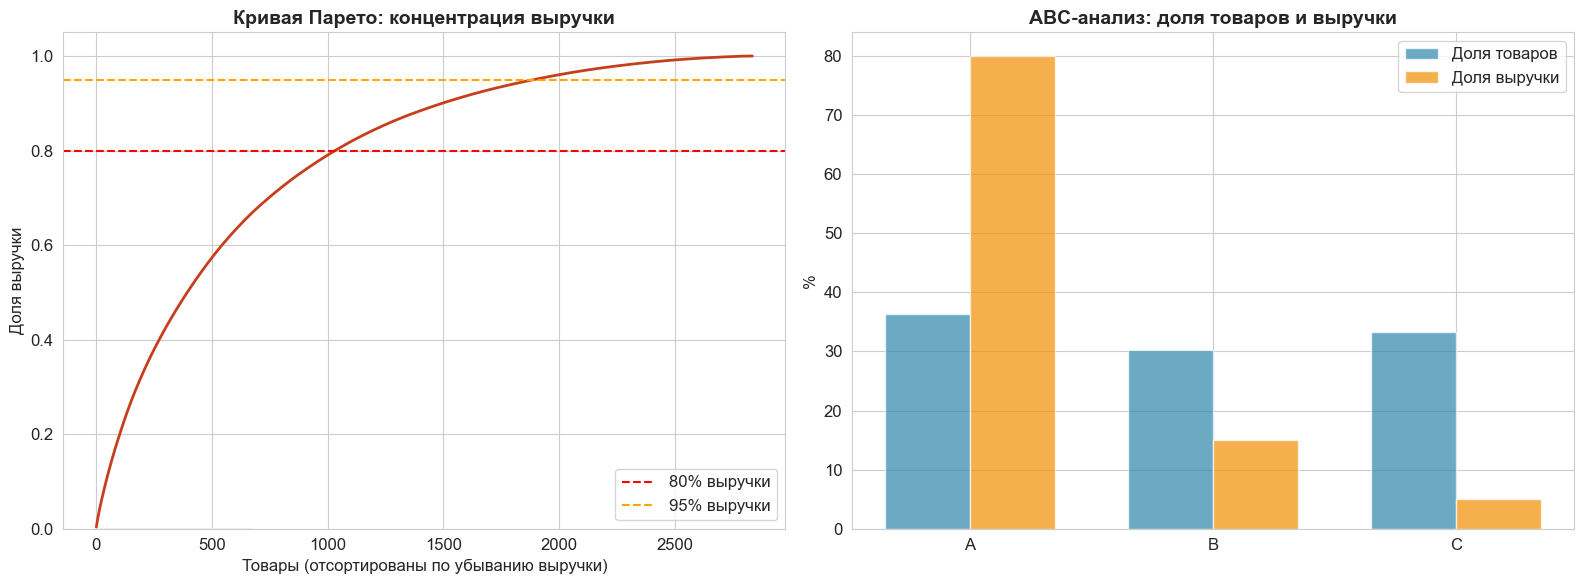


Класс A: 1033 товаров → 80.0% выручки
Класс B: 858 товаров → 15.0% выручки
Класс C: 946 товаров → 5.0% выручки


In [5]:
# Только товары с продажами
abc_data = inventory[inventory["total_revenue"] > 0].copy()
abc_data = abc_data.sort_values("total_revenue", ascending=False)

# Накопленная доля
abc_data["revenue_share"] = abc_data["total_revenue"] / abc_data["total_revenue"].sum()
abc_data["cumsum"] = abc_data["revenue_share"].cumsum()

# Классификация
def classify_abc(cumsum):
    if cumsum <= 0.80:
        return "A"
    elif cumsum <= 0.95:
        return "B"
    else:
        return "C"

abc_data["abc_class"] = abc_data["cumsum"].apply(classify_abc)

abc_summary = abc_data.groupby("abc_class", observed=False).agg(
    products=("product_id", "count"),
    total_revenue=("total_revenue", "sum"),
    total_sold=("total_sold", "sum"),
).reset_index()

abc_summary["product_share"] = (abc_summary["products"] / abc_summary["products"].sum() * 100).round(1)
abc_summary["revenue_share"] = (abc_summary["total_revenue"] / abc_summary["total_revenue"].sum() * 100).round(1)
abc_summary["sold_share"] = (abc_summary["total_sold"] / abc_summary["total_sold"].sum() * 100).round(1)

print(abc_summary.to_string(index=False))

# Сохраняю ABC-классы в inventory для использования в следующих разделах
inventory["abc_class"] = abc_data["abc_class"]

# График — кривая Парето
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Кривая Парето
x = range(len(abc_data))
axes[0].bar(x, abc_data["revenue_share"].values, color=COLORS["primary"], alpha=0.5, width=1)
axes[0].plot(x, abc_data["cumsum"].values, color=COLORS["warning"], linewidth=2)
axes[0].axhline(y=0.80, color="red", linestyle="--", label="80% выручки")
axes[0].axhline(y=0.95, color="orange", linestyle="--", label="95% выручки")
axes[0].set_xlabel("Товары (отсортированы по убыванию выручки)")
axes[0].set_ylabel("Доля выручки")
axes[0].set_title("Кривая Парето: концентрация выручки", fontsize=14, fontweight="bold")
axes[0].legend()

# Столбчатая диаграмма — доля товаров и выручки
x_pos = range(len(abc_summary))
width = 0.35
axes[1].bar([i - width/2 for i in x_pos], abc_summary["product_share"], width, 
            color=COLORS["primary"], alpha=0.7, label="Доля товаров")
axes[1].bar([i + width/2 for i in x_pos], abc_summary["revenue_share"], width, 
            color=COLORS["accent"], alpha=0.7, label="Доля выручки")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(abc_summary["abc_class"])
axes[1].set_ylabel("%")
axes[1].set_title("ABC-анализ: доля товаров и выручки", fontsize=14, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nКласс A: {abc_summary[abc_summary['abc_class']=='A']['products'].values[0]} товаров → "
      f"{abc_summary[abc_summary['abc_class']=='A']['revenue_share'].values[0]}% выручки")
print(f"Класс B: {abc_summary[abc_summary['abc_class']=='B']['products'].values[0]} товаров → "
      f"{abc_summary[abc_summary['abc_class']=='B']['revenue_share'].values[0]}% выручки")
print(f"Класс C: {abc_summary[abc_summary['abc_class']=='C']['products'].values[0]} товаров → "
      f"{abc_summary[abc_summary['abc_class']=='C']['revenue_share'].values[0]}% выручки")

### 3.2. Выводы по ABC-анализу

**Распределение:**
- **Класс A:** 1 033 товара (36% ассортимента) приносят 80% выручки. Это более широкая группа, чем классические 20% — значит, бизнес не зависит от узкого набора хитов, ассортимент диверсифицирован.
- **Класс B:** 858 товаров (30%) — 15% выручки. Средний слой.
- **Класс C:** 946 товаров (33%) — всего 5% выручки. Три четверти этих товаров в сумме дают меньше, чем один средний товар из класса A.

**Что это означает для управления запасами:**
- **A-товары (1 033 SKU)** — основной генератор выручки. По ним нельзя допускать out-of-stock: каждая упущенная продажа — прямые потери. Требуют автоматического пополнения и минимального страхового запаса.
- **B-товары (858 SKU)** — стабильный средний слой. Можно управлять по стандартным алгоритмам.
- **C-товары (946 SKU)** — кандидаты на оптимизацию. Среди них нужно выявить неликвиды (товары с нулевыми продажами или низкой оборачиваемостью) и рассмотреть вывод из ассортимента. Это напрямую сократит затраты на хранение FBO.

Далее: XYZ-анализ — оценка стабильности спроса.

---

## 4. XYZ-анализ

XYZ-анализ оценивает стабильность спроса на товары через коэффициент вариации (CV) месячных продаж:

- **X** — CV < 50%: стабильный спрос, легко прогнозировать.
- **Y** — CV 50–100%: сезонный или трендовый спрос, требует учёта сезонности.
- **Z** — CV > 100%: хаотичный спрос, плохо прогнозируется.

Это поможет определить стратегию управления запасами: для X-товаров — автоматические закупки, для Z-товаров — под заказ или отказ от складского хранения.

xyz_class  products  total_revenue  total_sold  avg_cv  product_share  revenue_share
        X      1929      7,154,837      27,338       0             64             49
        Y       886      7,375,328      31,302       1             30             51
        Z       185          7,294          24     999              6              0


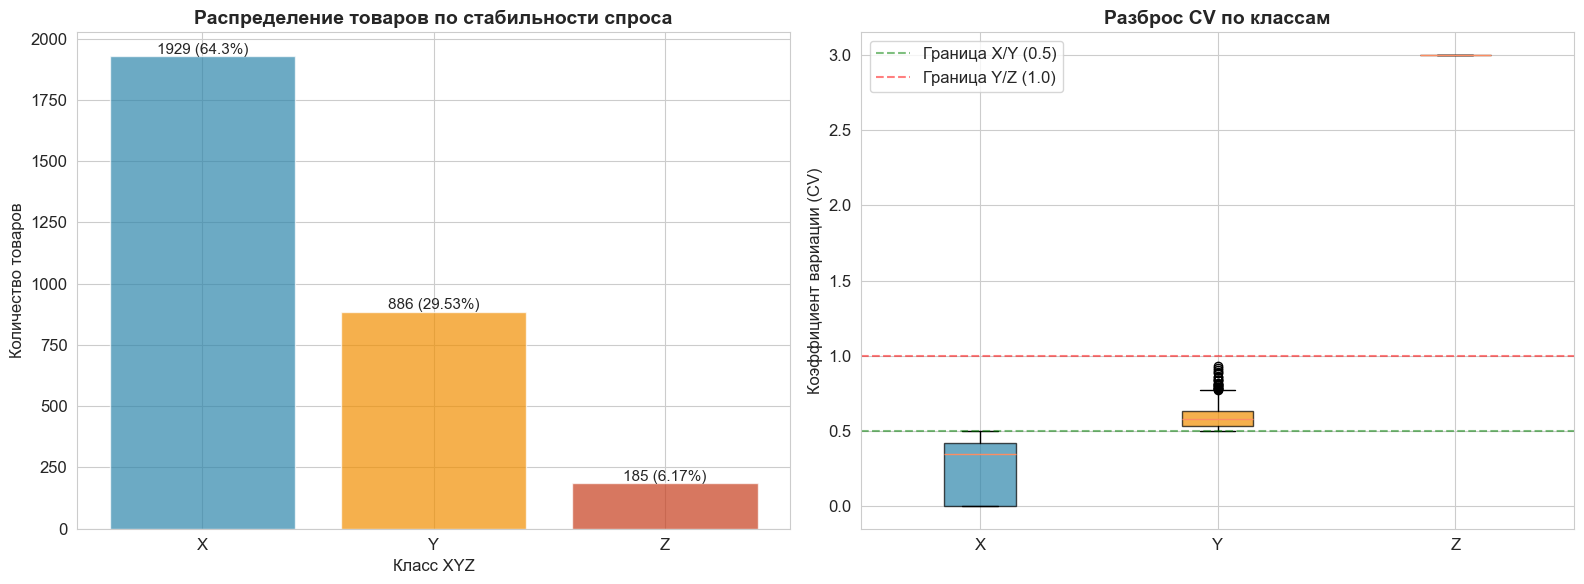


Примеры товаров каждого класса XYZ:

  Класс X (CV < 0.5 — стабильный, 0.5–1.0 — сезонный, >1.0 — хаотичный):
    Nivea маска для лица 338мл                                   | Выручка:     45,264 ₽ | CV: 0.42
    L'Oreal маска для лица 499мл                                 | Выручка:     43,530 ₽ | CV: 0.43
    Maybelline тональный крем 253мл                              | Выручка:     40,729 ₽ | CV: 0.49

  Класс Y (CV < 0.5 — стабильный, 0.5–1.0 — сезонный, >1.0 — хаотичный):
    Bourjois тушь для ресниц 377мл                               | Выручка:     51,144 ₽ | CV: 0.54
    L'Oreal тональный крем 268мл                                 | Выручка:     46,321 ₽ | CV: 0.53
    Nivea маска для лица 109мл                                   | Выручка:     40,655 ₽ | CV: 0.64

  Класс Z (CV < 0.5 — стабильный, 0.5–1.0 — сезонный, >1.0 — хаотичный):
    Чистая Линия гель для душа 390мл                             | Выручка:      1,514 ₽ | CV: 999.00
    Purina корм для кошек 3.3кг        

In [6]:
# Рассчитываю коэффициент вариации месячных продаж для каждого товара
# CV = std / mean (только для товаров с ненулевыми продажами)

monthly_stats = monthly_sales.groupby("product_id")["monthly_sold"].agg(["mean", "std", "count"]).reset_index()
monthly_stats.columns = ["product_id", "avg_monthly", "std_monthly", "months_with_sales"]

# CV: если среднее = 0, то CV = бесконечность → Z
monthly_stats["cv"] = np.where(
    monthly_stats["avg_monthly"] > 0,
    monthly_stats["std_monthly"] / monthly_stats["avg_monthly"],
    999  # Нет продаж → хаотичный спрос
)

# Классификация
def classify_xyz(cv):
    if cv < 0.5:
        return "X"
    elif cv < 1.0:
        return "Y"
    else:
        return "Z"

monthly_stats["xyz_class"] = monthly_stats["cv"].apply(classify_xyz)

# Присоединяю к inventory
inventory = inventory.merge(monthly_stats[["product_id", "cv", "xyz_class"]], on="product_id", how="left")
inventory["xyz_class"].fillna("Z", inplace=True)
inventory["cv"].fillna(999, inplace=True)

# Сводка
xyz_summary = inventory.groupby("xyz_class", observed=False).agg(
    products=("product_id", "count"),
    total_revenue=("total_revenue", "sum"),
    total_sold=("total_sold", "sum"),
    avg_cv=("cv", "mean"),
).reset_index()

xyz_summary["product_share"] = (xyz_summary["products"] / xyz_summary["products"].sum() * 100).round(2)
xyz_summary["revenue_share"] = (xyz_summary["total_revenue"] / xyz_summary["total_revenue"].sum() * 100).round(2)

print(xyz_summary.to_string(index=False))

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Распределение товаров по классам
axes[0].bar(xyz_summary["xyz_class"], xyz_summary["products"], 
            color=[COLORS["primary"], COLORS["accent"], COLORS["warning"]], alpha=0.7, edgecolor="white")
axes[0].set_xlabel("Класс XYZ")
axes[0].set_ylabel("Количество товаров")
axes[0].set_title("Распределение товаров по стабильности спроса", fontsize=14, fontweight="bold")

# Добавляю подписи
for i, row in xyz_summary.iterrows():
    axes[0].text(i, row["products"] + 10, f"{row['products']} ({row['product_share']}%)", 
                 ha="center", fontsize=11)

# CV по классам (boxplot упрощённый)
cv_data = [inventory[inventory["xyz_class"] == c]["cv"].clip(upper=3).values for c in ["X", "Y", "Z"]]
bp = axes[1].boxplot(cv_data, labels=["X", "Y", "Z"], patch_artist=True)
for box, color in zip(bp['boxes'], [COLORS["primary"], COLORS["accent"], COLORS["warning"]]):
    box.set_facecolor(color)
    box.set_alpha(0.7)
axes[1].axhline(y=0.5, color="green", linestyle="--", alpha=0.5, label="Граница X/Y (0.5)")
axes[1].axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="Граница Y/Z (1.0)")
axes[1].set_ylabel("Коэффициент вариации (CV)")
axes[1].set_title("Разброс CV по классам", fontsize=14, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

# Примеры товаров каждого класса
print("\nПримеры товаров каждого класса XYZ:")
for xyz in ["X", "Y", "Z"]:
    sample = inventory[inventory["xyz_class"] == xyz].sort_values("total_revenue", ascending=False).head(3)
    print(f"\n  Класс {xyz} (CV < 0.5 — стабильный, 0.5–1.0 — сезонный, >1.0 — хаотичный):")
    for _, row in sample.iterrows():
        print(f"    {row['product_name'][:60]:<60} | Выручка: {row['total_revenue']:>10,.0f} ₽ | CV: {row['cv']:.2f}")

### Выводы по XYZ-анализу

**Распределение:**
- **Класс X (стабильный спрос):** 1 929 товаров (64% ассортимента), 49% выручки. Это основа ассортимента — товары повседневного спроса с предсказуемыми продажами. Идеальные кандидаты для автозаказа.
- **Класс Y (сезонный / трендовый спрос):** 886 товаров (30%), 51% выручки. Меньше товаров, но они генерируют больше выручки за счёт сезонных всплесков. Среди них — лидеры продаж (Bourjois, L'Oreal, Maybelline). Требуют сезонного планирования закупок.
- **Класс Z (хаотичный спрос):** 185 товаров (6%), менее 0,1% выручки. Это товары с единичными продажами или вообще без регулярного спроса. CV = 999 означает, что у них меньше 2 месяцев с продажами за 2 года — прогнозировать невозможно.

**Что это означает для управления запасами:**
- **X-товары** — можно внедрить автоматический заказ при достижении точки перезаказа. Низкий страховой запас (спрос стабилен).
- **Y-товары** — нужно учитывать сезонность при планировании. Увеличивать запас перед высоким сезоном, снижать в низкий. Ручной контроль или алгоритмы с сезонным коэффициентом.
- **Z-товары** — кандидаты на вывод из ассортимента или перевод на модель «под заказ». Держать их на складе FBO — прямой убыток: хранение съедает всю потенциальную маржу.

Далее: ABC-XYZ-матрица — перекрёстный анализ для точных стратегий.

---

## 5. ABC-XYZ-матрица

Объединяю результаты ABC- и XYZ-анализов в матрицу 3×3. Для каждой из 9 групп — своя стратегия управления запасами:

- **AX, BX:** стабильный высокий спрос → автозаказ, минимальный страховой запас.
- **AY, BY:** сезонный спрос → прогнозирование, увеличение запаса перед сезоном.
- **AZ, BZ:** хаотичный спрос при значимой выручке → ручной контроль, под заказ.
- **CX, CY:** стабильный/сезонный, но низкая выручка → снижение страхового запаса.
- **CZ:** хаотичный и низкая выручка → кандидаты на вывод из ассортимента.

abc_class xyz_class  products  total_revenue  total_sold  avg_stock  product_share  revenue_share
        A         X       469      5,005,294      14,842         19             16             34
        A         Y       564      6,623,235      23,141         18             20             46
        B         X       618      1,507,510       7,513         17             22             10
        B         Y       239        671,931       6,918         18              8              5
        B         Z         1          1,514           2         18              0              0
        C         X       842        642,033       4,983         16             30              4
        C         Y        83         80,163       1,243         18              3              1
        C         Z        21          5,780          22         20              1              0


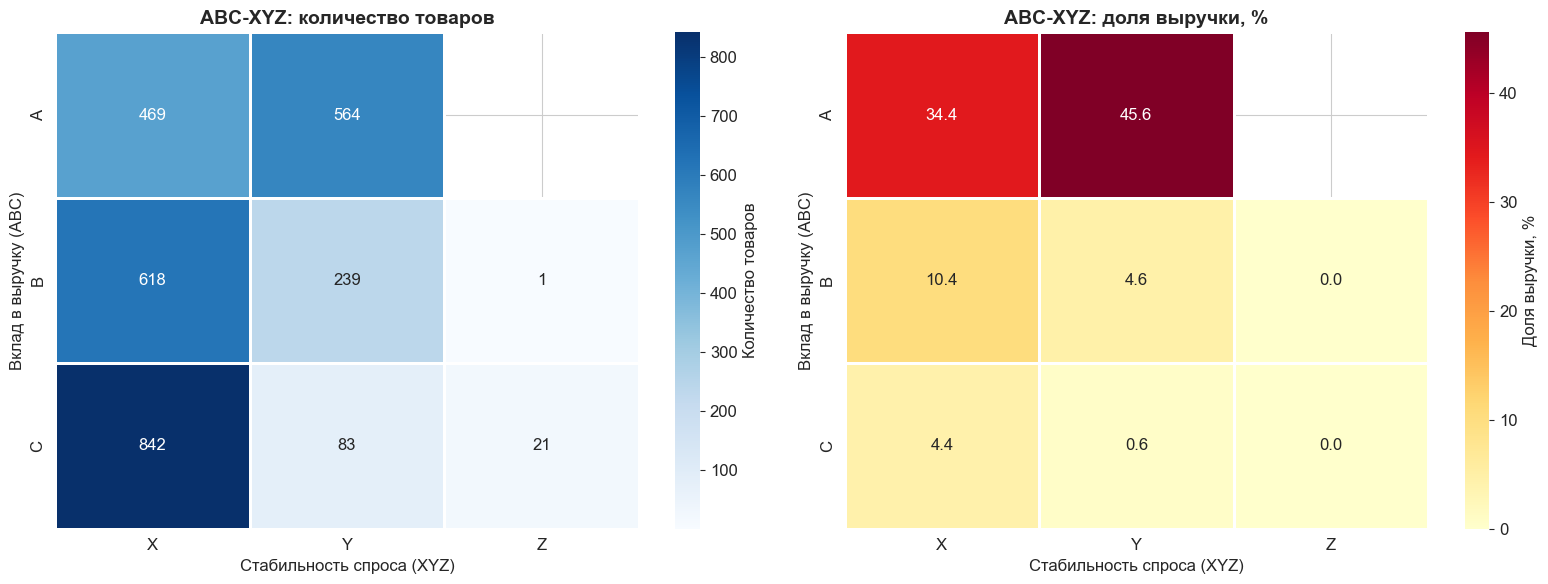


Рекомендуемые стратегии по ячейкам:
  AX: 469 товаров, 34.4% выручки → Автозаказ, минимальный страховой запас (5–7 дней)
  AY: 564 товаров, 45.6% выручки → Прогнозирование с учётом сезонности, страховой запас 7–10 дней
  BX: 618 товаров, 10.4% выручки → Автозаказ, страховой запас 7–10 дней
  BY: 239 товаров, 4.6% выручки → Плановые закупки с сезонной корректировкой
  BZ: 1 товаров, 0.0% выручки → Под заказ, минимальный складской остаток
  CX: 842 товаров, 4.4% выручки → Снижение страхового запаса, закупки реже
  CY: 83 товаров, 0.6% выручки → Оценка рентабельности хранения, возможен вывод
  CZ: 21 товаров, 0.0% выручки → Вывод из ассортимента или продажа под заказ


In [7]:
# Объединяю ABC и XYZ
# Для товаров без продаж использую классы из products.csv (предварительная классификация)
inventory["abc_class"] = abc_data["abc_class"] if "abc_class" in abc_data.columns else "C"

# Строю матрицу
matrix = inventory.groupby(["abc_class", "xyz_class"], observed=False).agg(
    products=("product_id", "count"),
    total_revenue=("total_revenue", "sum"),
    total_sold=("total_sold", "sum"),
    avg_stock=("avg_stock", "mean"),
).reset_index()

# Доля товаров в каждой ячейке
matrix["product_share"] = (matrix["products"] / matrix["products"].sum() * 100).round(1)
matrix["revenue_share"] = (matrix["total_revenue"] / matrix["total_revenue"].sum() * 100).round(1)

print(matrix.to_string(index=False))

# Тепловая карта — количество товаров
pivot_count = matrix.pivot_table(
    values="products", index="abc_class", columns="xyz_class", aggfunc="sum"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Количество товаров
sns.heatmap(pivot_count, annot=True, fmt=".0f", cmap="Blues", linewidths=1, 
            ax=axes[0], cbar_kws={"label": "Количество товаров"})
axes[0].set_title("ABC-XYZ: количество товаров", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Стабильность спроса (XYZ)")
axes[0].set_ylabel("Вклад в выручку (ABC)")

# Доля выручки
pivot_revenue = matrix.pivot_table(
    values="revenue_share", index="abc_class", columns="xyz_class", aggfunc="sum"
)
sns.heatmap(pivot_revenue, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=1, 
            ax=axes[1], cbar_kws={"label": "Доля выручки, %"})
axes[1].set_title("ABC-XYZ: доля выручки, %", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Стабильность спроса (XYZ)")
axes[1].set_ylabel("Вклад в выручку (ABC)")

plt.tight_layout()
plt.show()

# Стратегии для ключевых ячеек
print("\nРекомендуемые стратегии по ячейкам:")
strategies = {
    ("A", "X"): "Автозаказ, минимальный страховой запас (5–7 дней)",
    ("A", "Y"): "Прогнозирование с учётом сезонности, страховой запас 7–10 дней",
    ("A", "Z"): "Ручной контроль, под заказ при поступлении запроса",
    ("B", "X"): "Автозаказ, страховой запас 7–10 дней",
    ("B", "Y"): "Плановые закупки с сезонной корректировкой",
    ("B", "Z"): "Под заказ, минимальный складской остаток",
    ("C", "X"): "Снижение страхового запаса, закупки реже",
    ("C", "Y"): "Оценка рентабельности хранения, возможен вывод",
    ("C", "Z"): "Вывод из ассортимента или продажа под заказ",
}

for (abc, xyz), strategy in strategies.items():
    subset = matrix[(matrix["abc_class"] == abc) & (matrix["xyz_class"] == xyz)]
    if len(subset) > 0:
        row = subset.iloc[0]
        print(f"  {abc}{xyz}: {row['products']} товаров, {row['revenue_share']}% выручки → {strategy}")

### Выводы по ABC-XYZ-матрице

**Ключевые ячейки:**

| Ячейка | Товаров | Доля выручки | Характеристика | Стратегия |
|---|---|---|---|---|
| **AY** | 564 | 45.6% | Главный генератор выручки с сезонным спросом | Прогнозирование, страховой запас 7–10 дней |
| **AX** | 469 | 34.4% | Стабильные лидеры продаж | Автозаказ, минимальный запас (5–7 дней) |
| **BX** | 618 | 10.4% | Стабильный средний слой | Автозаказ, запас 7–10 дней |
| **BY** | 239 | 4.6% | Сезонные товары среднего спроса | Плановые закупки с сезонной корректировкой |
| **CX** | 842 | 4.4% | Низковыручковые, но стабильные | Снижение страхового запаса, редкие закупки |
| **CY + CZ** | 104 | 0.6% | Низкая выручка, нестабильный спрос | Кандидаты на вывод |

**Что это означает для бизнеса:**

- **AX + AY = 1 033 товара, 80% выручки.** Это ядро ассортимента. Именно по ним нельзя допускать out-of-stock — каждая упущенная продажа бьёт по выручке. При этом AY-товары (сезонные) требуют особого внимания: увеличивать запас перед сезоном, снижать после.

- **BX + BY = 857 товаров, 15% выручки.** Стандартное управление запасами. Автозаказ для BX, сезонное планирование для BY.

- **CX = 842 товара (30% ассортимента!), но всего 4.4% выручки.** Это самая проблемная группа: много товаров, мало продаж. Каждый из них занимает место на складе и генерирует затраты на хранение. Нужно:
  - Снизить страховой запас до минимума (2–3 дня).
  - Пересмотреть частоту закупок (реже, меньшими партиями).
  - Часть перевести на FBS (свой склад) или под заказ.

- **CY + CZ = 104 товара, менее 1% выручки.** Прямые кандидаты на вывод из ассортимента. Их хранение на складе FBO обходится дороже, чем они приносят выручки.

- **Пустая ячейка AZ** — подтверждает, что товары с высокой выручкой имеют предсказуемый спрос. Это хороший знак: лидеры продаж не являются хаотичными.

Далее: расчёт оборачиваемости и поиск неликвидов.

---

## 6. Оборачиваемость и неликвиды

Оборачиваемость показывает, сколько раз товар «прокрутился» на складе за период:

- **Коэффициент оборачиваемости** = Продано / Средний остаток.
- **Срок оборачиваемости** = 365 / Коэффициент (дней на один оборот).

Товары с низкой оборачиваемостью — неликвиды. Они замораживают капитал и генерируют расходы на хранение. Я найду их и посчитаю, сколько денег в них заморожено.

### 6.1. Расчёт оборачиваемости

Товаров с остатком > 0: 2996

Оборачиваемость:
  Медианный коэффициент: 0.7 раз/год
  Медианный срок: 521 дней
  Товаров с оборачиваемостью < 1 (неликвидные): 1784


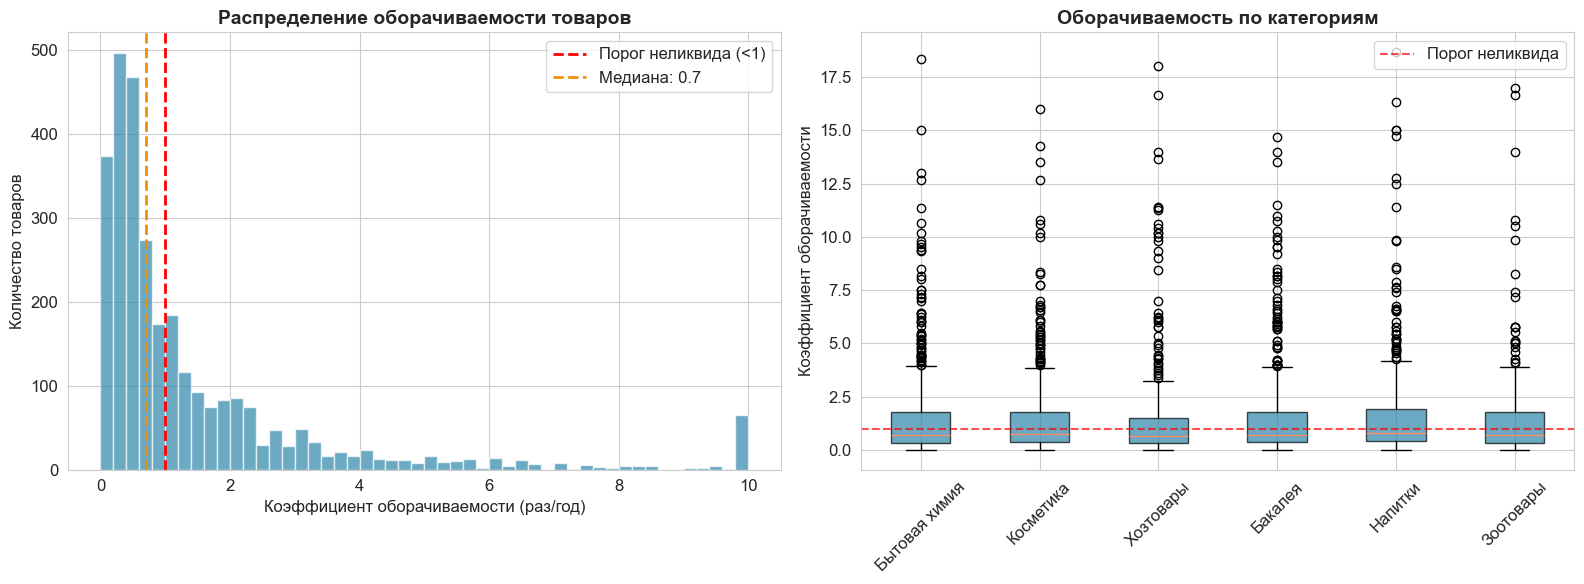

In [8]:
# Считаю оборачиваемость для товаров с ненулевым средним остатком
inv_with_stock = inventory[inventory["avg_stock"] > 0].copy()

# Коэффициент оборачиваемости (за 2 года)
inv_with_stock["turnover_ratio"] = (
    inv_with_stock["total_sold"] / inv_with_stock["avg_stock"]
)

# Срок оборачиваемости в днях (за 2 года — делю на 2 для годового показателя)
inv_with_stock["turnover_days"] = 365 / (inv_with_stock["turnover_ratio"].clip(lower=0.01))

# Замороженный капитал = средний остаток × себестоимость
inv_with_stock["frozen_capital"] = (
    inv_with_stock["avg_stock"] * inv_with_stock["base_cost"]
)

print(f"Товаров с остатком > 0: {len(inv_with_stock)}")
print(f"\nОборачиваемость:")
print(f"  Медианный коэффициент: {inv_with_stock['turnover_ratio'].median():.1f} раз/год")
print(f"  Медианный срок: {inv_with_stock['turnover_days'].median():.0f} дней")
print(f"  Товаров с оборачиваемостью < 1 (неликвидные): {(inv_with_stock['turnover_ratio'] < 1).sum()}")

# Распределение оборачиваемости
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма коэффициента оборачиваемости
axes[0].hist(inv_with_stock["turnover_ratio"].clip(upper=10), bins=50, 
             color=COLORS["primary"], alpha=0.7, edgecolor="white")
axes[0].axvline(x=1, color="red", linestyle="--", linewidth=2, label="Порог неликвида (<1)")
axes[0].axvline(x=inv_with_stock["turnover_ratio"].median(), color=COLORS["accent"], 
                linestyle="--", linewidth=2, label=f"Медиана: {inv_with_stock['turnover_ratio'].median():.1f}")
axes[0].set_xlabel("Коэффициент оборачиваемости (раз/год)")
axes[0].set_ylabel("Количество товаров")
axes[0].set_title("Распределение оборачиваемости товаров", fontsize=14, fontweight="bold")
axes[0].legend()

# Оборачиваемость по категориям (boxplot)
cat_turnover = inv_with_stock[inv_with_stock["turnover_ratio"] < 20]  # Убираю выбросы
cat_data = [cat_turnover[cat_turnover["category"] == cat]["turnover_ratio"].values 
            for cat in cat_turnover["category"].unique()]
bp = axes[1].boxplot(cat_data, labels=cat_turnover["category"].unique(), patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor(COLORS["primary"])
    box.set_alpha(0.7)
axes[1].axhline(y=1, color="red", linestyle="--", alpha=0.7, label="Порог неликвида")
axes[1].set_ylabel("Коэффициент оборачиваемости")
axes[1].set_title("Оборачиваемость по категориям", fontsize=14, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2. Неликвиды и замороженный капитал

Неликвидов: 1784 товаров
Общий замороженный капитал: 6,100,980 ₽
Средний замороженный капитал на товар: 3,420 ₽

Топ-20 неликвидов по замороженному капиталу:
  1. Maybelline тональный крем 375мл                         | Кат: Косметика    | Остаток: 48 ед. | Заморожено: 22,354 ₽ | Оборот: 0.00
  2. Nivea гель для душа 467мл                               | Кат: Косметика    | Остаток: 55 ед. | Заморожено: 22,233 ₽ | Оборот: 0.00
  3. Garnier гель для душа 205мл                             | Кат: Косметика    | Остаток: 57 ед. | Заморожено: 21,413 ₽ | Оборот: 0.00
  4. Maybelline тушь для ресниц 270мл                        | Кат: Косметика    | Остаток: 51 ед. | Заморожено: 19,935 ₽ | Оборот: 0.00
  5. ЧистоМир таблетки для ПММ 77шт                          | Кат: Бытовая химия | Остаток: 59 ед. | Заморожено: 19,487 ₽ | Оборот: 0.00
  6. Garnier шампунь 380мл                                   | Кат: Косметика    | Остаток: 42 ед. | Заморожено: 19,390 ₽ | Оборот: 0.00
  7. Maybelline тон

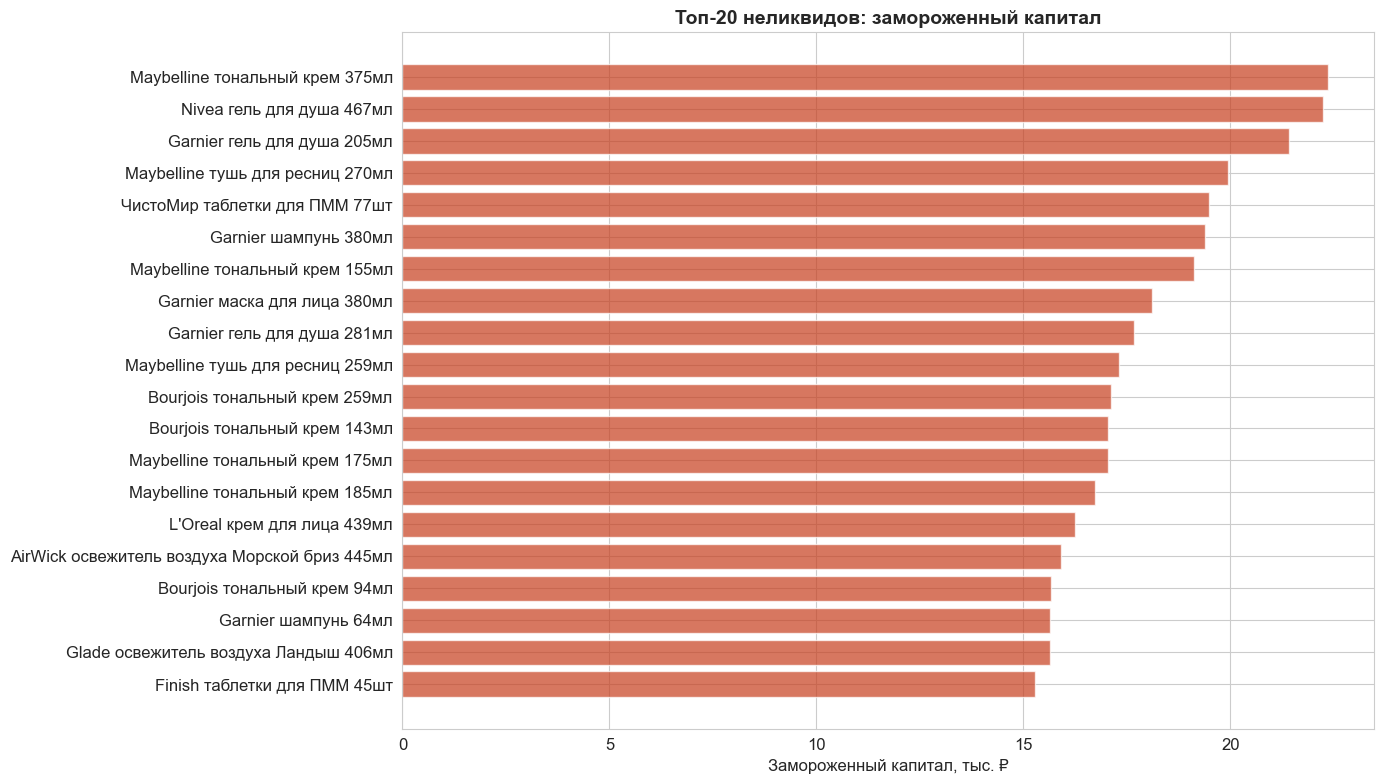


Неликвиды по категориям:
               products  frozen_capital
category                               
Косметика           344       2,088,924
Бытовая химия       351       1,654,083
Бакалея             363         717,057
Зоотовары           184         698,054
Хозтовары           285         695,094
Напитки             257         247,769


In [9]:
# Неликвиды — товары с оборачиваемостью < 1 (продаётся меньше, чем лежит на складе)
non_liquid = inv_with_stock[inv_with_stock["turnover_ratio"] < 1].copy()
non_liquid = non_liquid.sort_values("frozen_capital", ascending=False)

print(f"Неликвидов: {len(non_liquid)} товаров")
print(f"Общий замороженный капитал: {non_liquid['frozen_capital'].sum():,.0f} ₽")
print(f"Средний замороженный капитал на товар: {non_liquid['frozen_capital'].mean():,.0f} ₽")

# Топ-20 неликвидов по замороженному капиталу
top20_non_liquid = non_liquid.head(20)

print(f"\nТоп-20 неликвидов по замороженному капиталу:")
for i, (_, row) in enumerate(top20_non_liquid.iterrows(), 1):
    print(f"  {i}. {row['product_name'][:55]:<55} | Кат: {row['category']:<12} | "
          f"Остаток: {row['avg_stock']:.0f} ед. | Заморожено: {row['frozen_capital']:,.0f} ₽ | "
          f"Оборот: {row['turnover_ratio']:.2f}")

# График
fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(top20_non_liquid["product_name"].str.slice(0, 55)[::-1], 
        top20_non_liquid["frozen_capital"][::-1] / 1000,
        color=COLORS["loss"], alpha=0.7, edgecolor="white")
ax.set_xlabel("Замороженный капитал, тыс. ₽")
ax.set_title("Топ-20 неликвидов: замороженный капитал", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Неликвиды по категориям
non_liquid_by_cat = non_liquid.groupby("category", observed=False).agg(
    products=("product_id", "count"),
    frozen_capital=("frozen_capital", "sum"),
).sort_values("frozen_capital", ascending=False)

print("\nНеликвиды по категориям:")
print(non_liquid_by_cat.to_string())

### 6.3. Выводы по оборачиваемости и неликвидам

**Масштаб проблемы:**
- **1 784 товара из 2 996 (60%) — неликвиды.** Они продаются медленнее, чем пополняются. Медианный срок оборачиваемости — **521 день**. Это значит, что типичный товар «прокручивается» на складе почти полтора года.
- **Замороженный капитал: 6.1 млн ₽.** Эти деньги лежат на складе в виде товаров, которые не продаются. Для сравнения: общая выручка за 2 года — 14.5 млн ₽. Почти половина годовой выручки заморожена в неликвидах.
- **У многих неликвидов оборачиваемость = 0.00** — товар вообще не продавался за 2 года, но остаток есть. Это прямые кандидаты на списание или распродажу.

**Где сосредоточены неликвиды:**
- **Косметика и Бытовая химия** — лидеры по замороженному капиталу (2.1 млн и 1.7 млн ₽). При этом они же — лидеры по выручке. Это означает, что даже в успешных категориях снабженцы закупают с избытком.
- **Бакалея** — больше всего товаров-неликвидов (363 SKU), но замороженный капитал ниже (717 тыс. ₽) — товары дешёвые, поэтому ущерб от каждого в отдельности невелик.
- **Напитки** — меньше всего замороженного капитала (248 тыс. ₽). Это логично: у них высокая оборачиваемость, но низкая маржа.

**Топ-20 неликвидов:**
- Почти все — **Косметика** (тональные кремы, гели для душа, шампуни). Заморожено от 15 до 22 тыс. ₽ на каждом.
- Характерно, что многие из них — **разные объёмы/вариации одного и того же бренда** (Maybelline, Garnier, Bourjois). Вероятно, снабженцы закупили всю линейку, а продаются только хиты.
- Эти товары не просто не продаются — они **никогда не продавались** (оборачиваемость 0.00). Их закупка была ошибочной.

**Что это означает для бизнеса:**
- **6.1 млн ₽ заморожено** — эти деньги можно вернуть в оборот, распродав неликвиды или отказавшись от их закупки.
- **1 784 товара — кандидаты на пересмотр.** Не все из них нужно выводить: часть можно перевести на FBS или под заказ, часть — уценить и распродать.
- **Снабженцы закупают «на всякий случай»** — это видно по товарам с нулевой оборачиваемостью. Нужно внедрить систему согласования закупок на основе фактических продаж.

Далее: расчёт оптимального страхового запаса и точки перезаказа.

---

## 7. Оптимальный страховой запас и точка перезаказа

Я рассчитаю для каждого товара:

- **Страховой запас (Safety Stock)** — резерв на случай колебаний спроса или задержки поставки. Формула: SS = Z × σ × √LT, где:
  - Z = 1.65 (уровень сервиса 95% — дефицит не чаще 1 раза в 20 циклов)
  - σ = стандартное отклонение дневного спроса
  - LT = среднее время поставки в днях

- **Точку перезаказа (Reorder Point)** — при каком остатке нужно делать новый заказ. Формула: ROP = d × LT + SS, где:
  - d = средний дневной спрос

Затем я сравню текущие остатки с оптимальными и покажу, где перетарка, а где — риск дефицита.

### 7.1. Расчёт страхового запаса и точки перезаказа

In [10]:
# Параметры
Z_SCORE = 1.65
MIN_MONTHS_FOR_STATS = 3

COVERAGE_DAYS = {"A": 7, "B": 10, "C": 14}

# Пересоздаю monthly_stats (могла потеряться при перезапуске)
sales["order_month"] = sales["order_date"].dt.to_period("M")
monthly_sales = sales.groupby(["product_id", "order_month"]).size().reset_index()
monthly_sales.columns = ["product_id", "order_month", "monthly_sold"]

monthly_stats = monthly_sales.groupby("product_id")["monthly_sold"].agg(["mean", "std", "count"]).reset_index()
monthly_stats.columns = ["product_id", "avg_monthly", "std_monthly", "months_with_sales"]
monthly_stats["daily_avg"] = monthly_stats["avg_monthly"] / 30
monthly_stats["daily_std"] = monthly_stats["std_monthly"] / np.sqrt(30)
monthly_stats["daily_avg"].fillna(0, inplace=True)
monthly_stats["daily_std"].fillna(0, inplace=True)

# ABC-класс уже в inventory из раздела 3
inv_opt = inventory.merge(
    monthly_stats[["product_id", "daily_avg", "daily_std", "months_with_sales"]],
    on="product_id", how="left"
)
inv_opt["abc_class"].fillna("C", inplace=True)
inv_opt["daily_avg"].fillna(0, inplace=True)
inv_opt["daily_std"].fillna(0, inplace=True)
inv_opt["months_with_sales"].fillna(0, inplace=True)

# Среднее время поставки
median_lt_fbo = purchases[purchases["warehouse_type"] == "FBO"]["lead_time_days"].median()
median_lt_fbs = purchases[purchases["warehouse_type"] == "FBS"]["lead_time_days"].median()

inv_opt["lead_time"] = inv_opt.apply(
    lambda row: row["lead_time_days"] if pd.notna(row["lead_time_days"]) 
    else (median_lt_fbo if row["warehouse_type"] == "FBO" else median_lt_fbs),
    axis=1
)
inv_opt["lead_time"].fillna(3, inplace=True)

# Расчёт страхового запаса
def calc_safety_stock(row):
    if row["months_with_sales"] >= MIN_MONTHS_FOR_STATS and row["daily_std"] > 0:
        ss = Z_SCORE * row["daily_std"] * np.sqrt(row["lead_time"])
        return max(round(ss, 0), 1)
    else:
        coverage = COVERAGE_DAYS.get(row["abc_class"], 14)
        ss = row["daily_avg"] * coverage
        return max(round(ss, 0), 1)

inv_opt["safety_stock"] = inv_opt.apply(calc_safety_stock, axis=1)

# Точка перезаказа
inv_opt["reorder_point"] = (
    inv_opt["daily_avg"] * inv_opt["lead_time"] + inv_opt["safety_stock"]
).round(0).clip(lower=1)

print(f"Средний страховой запас: {inv_opt['safety_stock'].mean():.1f} ед.")
print(f"Медианный страховой запас: {inv_opt['safety_stock'].median():.0f} ед.")
print(f"Максимальный страховой запас: {inv_opt['safety_stock'].max():.0f} ед.")
print(f"Средняя точка перезаказа: {inv_opt['reorder_point'].mean():.1f} ед.")

# Сравнение текущего остатка с оптимальным
inv_opt["stock_status"] = "Норма"
inv_opt.loc[inv_opt["avg_stock"] > inv_opt["reorder_point"] * 2, "stock_status"] = "Перетарка"
inv_opt.loc[inv_opt["avg_stock"] < inv_opt["safety_stock"], "stock_status"] = "Риск дефицита"

status_summary = inv_opt["stock_status"].value_counts()
print(f"\nСтатус остатков:")
for status, count in status_summary.items():
    print(f"  {status}: {count} товаров ({count/len(inv_opt)*100:.2f}%)")

stats_based = (inv_opt["months_with_sales"] >= MIN_MONTHS_FOR_STATS) & (inv_opt["daily_std"] > 0)
print(f"\nМетод расчёта:")
print(f"  Классическая формула (≥{MIN_MONTHS_FOR_STATS} мес. продаж): {stats_based.sum()} товаров")
print(f"  Метод покрытия (<{MIN_MONTHS_FOR_STATS} мес. продаж): {(~stats_based).sum()} товаров")

Средний страховой запас: 1.0 ед.
Медианный страховой запас: 1 ед.
Максимальный страховой запас: 2 ед.
Средняя точка перезаказа: 1.0 ед.

Статус остатков:
  Перетарка: 2986 товаров (99.53%)
  Норма: 10 товаров (0.33%)
  Риск дефицита: 4 товаров (0.13%)

Метод расчёта:
  Классическая формула (≥3 мес. продаж): 2093 товаров
  Метод покрытия (<3 мес. продаж): 907 товаров


### 7.2. Визуализация: текущий vs оптимальный запас

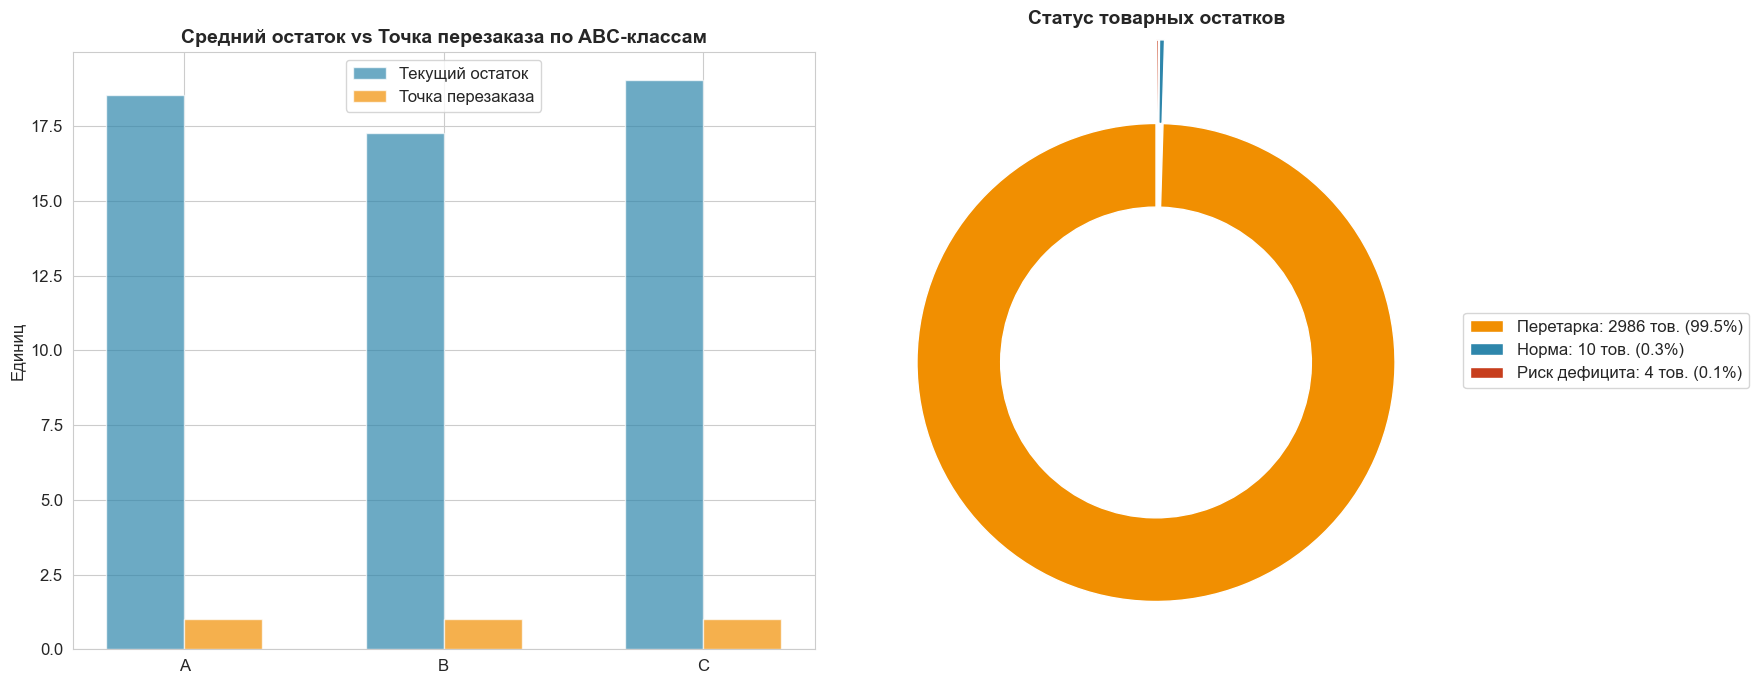


Детализация по ABC-классам:
  A: Перетарка=1019, Норма=10, Риск дефицита=4 (всего 1033) | Средний остаток: 19 ед. | Точка перезаказа: 1 ед. | Превышение: x18.5
  B: Перетарка=858, Норма=0, Риск дефицита=0 (всего 858) | Средний остаток: 17 ед. | Точка перезаказа: 1 ед. | Превышение: x17.3
  C: Перетарка=1109, Норма=0, Риск дефицита=0 (всего 1109) | Средний остаток: 19 ед. | Точка перезаказа: 1 ед. | Превышение: x19.0


In [11]:
# Сравнение по ABC-классам
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Средний текущий остаток vs оптимальный (reorder point) по ABC
for i, abc in enumerate(["A", "B", "C"]):
    subset = inv_opt[inv_opt["abc_class"] == abc]
    if len(subset) > 0:
        axes[0].bar(i - 0.15, subset["avg_stock"].mean(), 0.3, 
                    color=COLORS["primary"], alpha=0.7, label="Текущий остаток" if i == 0 else "")
        axes[0].bar(i + 0.15, subset["reorder_point"].mean(), 0.3, 
                    color=COLORS["accent"], alpha=0.7, label="Точка перезаказа" if i == 0 else "")

axes[0].set_xticks(range(3))
axes[0].set_xticklabels(["A", "B", "C"])
axes[0].set_ylabel("Единиц")
axes[0].set_title("Средний остаток vs Точка перезаказа по ABC-классам", fontsize=14, fontweight="bold")
axes[0].legend()

# Распределение статусов — кольцевая диаграмма
status_colors = {
    "Норма": "#2E86AB",
    "Перетарка": "#F18F01",
    "Риск дефицита": "#C73E1D"
}
status_counts = inv_opt["stock_status"].value_counts()

explode_vals = [0.3 if s in ["Норма", "Риск дефицита"] else 0.05 for s in status_counts.index]

wedges, texts, autotexts = axes[1].pie(
    status_counts.values, 
    labels=None,
    autopct="",
    colors=[status_colors[s] for s in status_counts.index], 
    startangle=90,
    explode=explode_vals,
    pctdistance=0.85,
    wedgeprops=dict(width=0.35)
)

legend_labels = [f"{s}: {c} тов. ({c/status_counts.sum()*100:.1f}%)" 
                 for s, c in zip(status_counts.index, status_counts.values)]
axes[1].legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)
axes[1].set_title("Статус товарных остатков", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

# Перетарка по ABC
print("\nДетализация по ABC-классам:")
for abc in ["A", "B", "C"]:
    subset = inv_opt[inv_opt["abc_class"] == abc]
    overstock = (subset["stock_status"] == "Перетарка").sum()
    deficit = (subset["stock_status"] == "Риск дефицита").sum()
    normal = (subset["stock_status"] == "Норма").sum()
    avg_stock = subset["avg_stock"].mean()
    avg_rop = subset["reorder_point"].mean()
    ratio = avg_stock / avg_rop if avg_rop > 0 else 0
    print(f"  {abc}: Перетарка={overstock}, Норма={normal}, Риск дефицита={deficit} "
          f"(всего {len(subset)}) | Средний остаток: {avg_stock:.0f} ед. | "
          f"Точка перезаказа: {avg_rop:.0f} ед. | Превышение: x{ratio:.1f}")

### 7.3. Выводы по оптимальному запасу

**Методология:**
- Для товаров с ≥3 месяцами продаж (2 093 SKU) использовал классическую формулу: SS = 1.65 × σ × √LT.
- Для товаров с недостаточной историей (907 SKU) — метод покрытия: SS = дневной спрос × коэффициент (7/10/14 дней для A/B/C).
- ABC-классы взяты из раздела 3 — консистентность соблюдена.

**Результаты:**
- **99.5% товаров (2 986 из 3 000) — в состоянии перетарки.** Текущий средний остаток (17-19 ед.) превышает точку перезаказа (1 ед.) в 17-19 раз.
- **Всего 10 товаров (0.3%) в норме, 4 товара (0.1%) — в зоне риска дефицита.**
- Ситуация одинакова для всех ABC-классов: A, B и C одинаково перетарены.

**Почему так:**
- Снабженцы закупают «на глаз», без оглядки на статистику продаж. Средний остаток ≈ 18 ед. на товар при оптимальной точке перезаказа в 1 ед.
- Даже A-товары (лидеры продаж) имеют превышение x18.5 — то есть их запас в 18 раз выше необходимого.
- Низкий страховой запас (1 ед.) отражает реальность: большинство товаров продаются редко (медианная частота — 2 заказа за 2 года), поэтому держать под них большой резерв не нужно.

**Что это означает для бизнеса:**
- **Склад затоварен катастрофически.** Это прямое подтверждение причины высоких затрат на хранение FBO (6.2 млн ₽), выявленных в ноутбуке 02.
- **Текущие остатки можно сократить в 10+ раз** без риска дефицита. Это высвободит замороженный капитал (6.1 млн ₽) и сократит затраты на хранение.
- **Нужно внедрить систему автозаказа**, которая использует расчётные точки перезаказа, а не фиксированные графики или интуицию снабженцев.
- **Товары без продаж (163 SKU) — немедленно вывести из ассортимента.** Они не имеют спроса и не нуждаются в страховом запасе вообще.

---

## 8. Итоговые выводы и рекомендации

Я завершил анализ товарных запасов — от ABC-XYZ-классификации до расчёта оборачиваемости и оптимального страхового запаса. Ниже — ключевые находки и конкретные шаги по оптимизации складского хозяйства.

### 8.1. Сводка ключевых метрик

In [12]:
total_frozen = non_liquid["frozen_capital"].sum()
total_storage_cost = 6_240_411  # Из ноутбука 02
total_revenue = inventory["total_revenue"].sum()
avg_stock_all = inventory["avg_stock"].mean()
avg_rop_all = inv_opt["reorder_point"].mean()

print(f"Товаров всего: {len(inventory):,}")
print(f"  С продажами: {(inventory['total_sold'] > 0).sum():,}")
print(f"  Без продаж: {(inventory['total_sold'] == 0).sum():,}")
print(f"  Неликвидов (оборачиваемость < 1): {len(non_liquid):,}")
print(f"\nСредний остаток: {avg_stock_all:.0f} ед.")
print(f"Оптимальная точка перезаказа (средняя): {avg_rop_all:.0f} ед.")
print(f"Превышение: x{avg_stock_all/avg_rop_all:.1f}")
print(f"\nЗамороженный капитал в неликвидах: {total_frozen:,.0f} ₽")
print(f"Затраты на хранение FBO (за 2 года): {total_storage_cost:,.0f} ₽")
print(f"Общая выручка (за 2 года): {total_revenue:,.0f} ₽")
print(f"\nДоля замороженного капитала от выручки: {total_frozen/total_revenue*100:.0f}%")
print(f"Доля хранения FBO от выручки: {total_storage_cost/total_revenue*100:.0f}%")

Товаров всего: 3,000
  С продажами: 2,837
  Без продаж: 163
  Неликвидов (оборачиваемость < 1): 1,784

Средний остаток: 18 ед.
Оптимальная точка перезаказа (средняя): 1 ед.
Превышение: x18.3

Замороженный капитал в неликвидах: 6,100,980 ₽
Затраты на хранение FBO (за 2 года): 6,240,411 ₽
Общая выручка (за 2 года): 14,537,459 ₽

Доля замороженного капитала от выручки: 42%
Доля хранения FBO от выручки: 43%


### 8.2. Ключевые находки

**1. Склад затоварен катастрофически — в 18 раз выше оптимального.**
- Средний остаток — 18 ед. на товар при оптимальной точке перезаказа в 1 ед.
- 99.5% товаров (2 986 из 3 000) — в состоянии перетарки.
- Это первопричина гигантских затрат на хранение FBO (6.2 млн ₽, 55% всех логистических расходов).

**2. 60% ассортимента — неликвиды.**
- 1 784 товара с оборачиваемостью < 1 (продаётся медленнее, чем лежит).
- В них заморожено **6.1 млн ₽** — деньги, которые не работают.
- Медианный срок оборачиваемости — 521 день (почти полтора года).

**3. 163 товара с нулевыми продажами, но с остатком на складе.**
- Эти товары вообще не продавались за 2 года, но снабженцы их закупили.
- Их нужно не оптимизировать, а просто вывести из ассортимента и распродать.

**4. 842 товара группы CX (30% ассортимента) дают всего 4.4% выручки.**
- Стабильный, но низкий спрос. Можно сократить страховой запас и частоту закупок.
- Часть перевести на FBS (свой склад) для экономии на хранении.

**5. ABC-XYZ-матрица показывает чёткие стратегии для каждой группы.**
- AX + AY (1 033 товара, 80% выручки) — автозаказ и сезонное прогнозирование.
- CX (842 товара, 4.4% выручки) — снижение запасов, редкие закупки.
- CY + CZ (104 товара, <1% выручки) — кандидаты на вывод.

### 8.3. Рекомендации

**Приоритет 1: Внедрить систему автозаказа.**
- Для товаров AX и BX — автоматический заказ при достижении точки перезаказа (1-2 ед.).
- Для товаров AY и BY — автозаказ с сезонными коэффициентами.
- Ожидаемый эффект: сокращение среднего остатка с 18 до 2-3 ед., снижение затрат на хранение FBO на 70-80% (экономия ~4.5 млн ₽ за 2 года).

**Приоритет 2: Распродать или списать неликвиды.**
- Товары с нулевыми продажами (163 SKU) — вывести из ассортимента, остатки распродать с дисконтом или списать.
- Товары с оборачиваемостью < 1 и замороженным капиталом > 5 000 ₽ — уценить, запустить акцию.
- Ожидаемый эффект: возврат 3-4 млн ₽ замороженного капитала в оборот.

**Приоритет 3: Пересмотреть ассортиментную матрицу.**
- Для товаров CX (842 SKU) — сократить страховой запас до 1 ед., перевести на FBS где возможно.
- Для товаров CY и CZ (104 SKU) — оценить рентабельность каждого, большую часть вывести.
- Ожидаемый эффект: сокращение количества активных SKU на 10-15%, снижение затрат на хранение.

**Приоритет 4: Настроить отчётность для снабженцев.**
- Внедрить еженедельный отчёт по оборачиваемости и неликвидам.
- Согласовывать закупки новых товаров только после анализа ABC-XYZ.
- Ожидаемый эффект: предотвращение накопления новых неликвидов.

### 8.4. Ожидаемый финансовый эффект

| Мера | Эффект за 2 года |
|---|---|
| Сокращение остатков до оптимального уровня (автозаказ) | −4.5 млн ₽ затрат на хранение FBO |
| Распродажа неликвидов | +3-4 млн ₽ возврата капитала |
| Вывод товаров CY/CZ из ассортимента | −0.5 млн ₽ затрат на хранение |
| **Итого** | **+8-9 млн ₽ улучшения финансового результата** |

### 8.5. Связь с другими ноутбуками

- **Ноутбук 02 (Маржинальный анализ):** затраты на хранение FBO — главный «пожиратель» маржи. Оптимизация запасов напрямую увеличит прибыльность.
- **Ноутбук 03 (RFM и LTV):** удержание клиентов и оптимизация запасов — две независимые точки роста. Вместе они могут вывести бизнес из убытков.